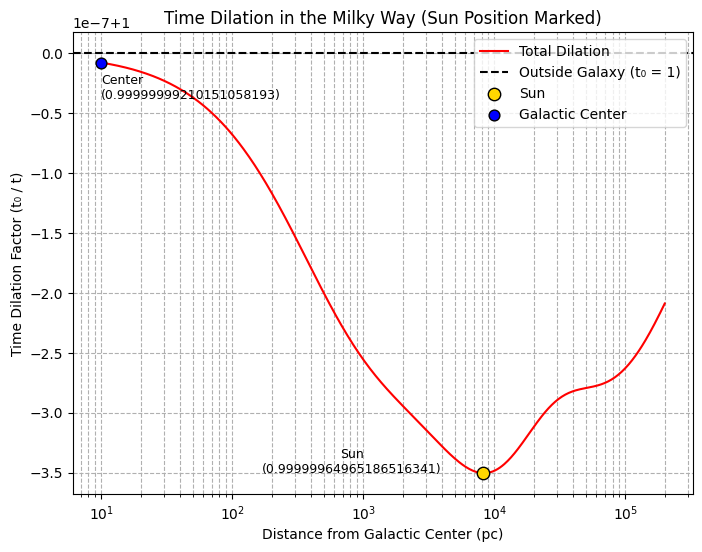

At Sun's orbit (~8.2 kpc): Total time dilation = 0.99999964965186516341
Cumulative time difference over 1 billion years vs outside galaxy ~ 350.35 years slower


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from ipywidgets import interact, FloatLogSlider

# ---------------------------
# Constants
# ---------------------------
G = 6.67430e-11        # gravitational constant, m^3 kg^-1 s^-2
c = 299792458          # speed of light, m/s
solar_mass = 1.989e30  # kg
pc_to_m = 3.086e16
kpc_to_m = 1e3 * pc_to_m

# ---------------------------
# Galaxy Model (Changeable)
# ---------------------------
def galaxy_parameters(name="Milky Way"):
    if name.lower() == "andromeda":
        return {
            "M_bulge": 3e10 * solar_mass,
            "M_disk": 1e11 * solar_mass,
            "M_halo": 1.5e12 * solar_mass,
            "R_bulge": 1.5 * kpc_to_m,
            "R_disk": 6.5 * kpc_to_m,
            "R_halo": 60 * kpc_to_m
        }
    else:  # Default Milky Way
        return {
            "M_bulge": 1e10 * solar_mass,
            "M_disk": 6e10 * solar_mass,
            "M_halo": 1e12 * solar_mass,
            "R_bulge": 1 * kpc_to_m,
            "R_disk": 5 * kpc_to_m,
            "R_halo": 50 * kpc_to_m
        }

params = galaxy_parameters("Milky Way")

# ---------------------------
# Functions
# ---------------------------
def enclosed_mass(r):
    M_b = params["M_bulge"] * (r**2 / (r + params["R_bulge"])**2)
    M_d = params["M_disk"] * (1 - np.exp(-r / params["R_disk"]) * (1 + r / params["R_disk"]))
    M_h = params["M_halo"] * (r**3 / (r + params["R_halo"])**3)
    return M_b + M_d + M_h

def orbital_velocity(r):
    return np.sqrt(G * enclosed_mass(r) / r)

def time_dilation_gravitational(r):
    return np.sqrt(1 - (2 * G * enclosed_mass(r)) / (r * c**2))

def time_dilation_velocity(r):
    v = orbital_velocity(r)
    return np.sqrt(1 - (v**2 / c**2))

def total_time_dilation(r):
    return time_dilation_gravitational(r) * time_dilation_velocity(r)

# ---------------------------
# Compute Profiles
# ---------------------------
radii = np.logspace(np.log10(0.01*kpc_to_m), np.log10(200*kpc_to_m), 500)
t_total = total_time_dilation(radii)

# Sun position
r_sun = 8.2 * kpc_to_m
t_sun = total_time_dilation(r_sun)

# ---------------------------
# Static Plot with Sun Position
# ---------------------------
plt.figure(figsize=(8,6))
plt.plot(radii/pc_to_m, t_total, 'r', label="Total Dilation")
plt.axhline(1, color='black', linestyle='--', label="Outside Galaxy (t₀ = 1)")

# Mark the Sun
plt.scatter(r_sun/pc_to_m, t_sun, color="gold", s=80, edgecolors="black", zorder=5, label="Sun")
plt.text(r_sun/pc_to_m*.1, t_sun, f"Sun\n({t_sun:.20f})", ha="center", fontsize=9)

# Mark Galactic Center (approx first point)
plt.scatter(radii[0]/pc_to_m, t_total[0], color="blue", s=60, edgecolors="black", zorder=5, label="Galactic Center")
plt.text(radii[0]/pc_to_m, t_total[0]-0.3e-7, f"Center\n({t_total[0]:.20f})", fontsize=9)

plt.xscale("log")
plt.xlabel("Distance from Galactic Center (pc)")
plt.ylabel("Time Dilation Factor (t₀ / t)")
plt.title("Time Dilation in the Milky Way (Sun Position Marked)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# ---------------------------
# Print Example
# ---------------------------
billion_years = 1e9 * 365 * 24 * 3600
t_far = 1.0
diff_sun_far = (1 - t_sun / t_far) * billion_years
print(f"At Sun's orbit (~8.2 kpc): Total time dilation = {t_sun:.20f}")
print(f"Cumulative time difference over 1 billion years vs outside galaxy ~ {diff_sun_far/(365*24*3600):.2f} years slower")
